# Implementação e Análise de uma Máquina de Turing para a Linguagem dos Grafos Bipartidos

# 1. INTRODUÇÃO

## Linguagem Escolhida

Neste trabalho será estudada a Linguagem dos Grafos Bipartidos (LGB).

A linguagem é definida como:


```
LGB = { <G> | G é um grafo bipartido }
```

Um grafo é bipartido quando seus vértices podem ser divididos em dois conjuntos disjuntos de forma que nenhuma aresta conecte vértices pertencentes ao mesmo conjunto.

## Motivação

O problema de verificação de bipartição é um problema clássico da Teoria dos Grafos e da Ciência da Computação.

Ele possui aplicações em problemas de alocação, escalonamento, redes de comunicação e modelagem de relacionamentos.

Neste trabalho será construída uma Máquina de Turing que decide se um grafo pertence ou não à linguagem LGB.

# 2. DEFINIÇÃO FORMAL DA MT

## Codificação da Entrada

Um grafo $G=(V,E)$ será representado na fita por uma palavra da forma:

```text
n#u1,v1;u2,v2;...;um,vm
```

onde:

* $n$ representa a quantidade de vértices do grafo;
* cada par $(u_i,v_i)$ representa uma aresta;
* o símbolo "#" separa o número de vértices da lista de arestas;
* o símbolo ";" separa as arestas;
* o símbolo "," separa os vértices de cada aresta.

Exemplo:

```text
4#1,2;2,3;3,4
```

representa o grafo:

```text
V = {1,2,3,4}
E = {(1,2),(2,3),(3,4)}
```

---

## Linguagem

A linguagem estudada neste trabalho é:

$$
LGB={\langle G\rangle \mid G \text{ é um grafo bipartido}}
$$

Ou seja, a linguagem contém todas as codificações de grafos bipartidos.

---

## Estratégia de Decisão

A Máquina de Turing decide a linguagem LGB verificando se o grafo admite uma coloração com apenas duas cores.

A estratégia utilizada é:

1. Ler a codificação do grafo.
2. Selecionar um vértice ainda não colorido.
3. Atribuir a ele uma cor inicial.
4. Atribuir aos seus vizinhos a cor oposta.
5. Repetir o processo para todos os vértices alcançáveis.
6. Caso dois vértices adjacentes recebam a mesma cor, rejeitar a entrada.
7. Caso todo o grafo seja colorido sem conflitos, aceitar a entrada.

Essa estratégia corresponde ao algoritmo clássico de verificação de bipartição utilizando busca em largura (BFS).

---

## Definição Formal

A Máquina de Turing é definida pela 7-upla:

$$
M=(Q,\Sigma,\Gamma,\delta,q_0,\square,F)
$$

---

### Conjunto de Estados (Q)

$$
Q=
{
q_0,
q_{Leitura},
q_{Colorir},
q_{Verificar},
q_{Accept},
q_{Reject}
}
$$

---

### Descrição dos Estados

| Estado          | Função                                                               |
| --------------- | -------------------------------------------------------------------- |
| $q_0$           | Estado inicial                                                       |
| $q_{Leitura}$   | Realiza a leitura da entrada e interpretação da codificação do grafo |
| $q_{Colorir}$   | Executa a atribuição de cores aos vértices                           |
| $q_{Verificar}$ | Verifica conflitos de coloração                                      |
| $q_{Accept}$    | Estado de aceitação                                                  |
| $q_{Reject}$    | Estado de rejeição                                                   |

---

### Alfabeto de Entrada ($\Sigma$)

$$
\Sigma=
{
0,1,2,3,4,5,6,7,8,9,#,;,\texttt{,}
}
$$

Os símbolos de entrada são suficientes para representar qualquer grafo segundo a codificação adotada.

---

### Alfabeto da Fita ($\Gamma$)

$$
\Gamma=
\Sigma
\cup
{
R,G,X,\square
}
$$

onde:

| Símbolo   | Significado                        |
| --------- | ---------------------------------- |
| $R$       | Vértice marcado com a primeira cor |
| $G$       | Vértice marcado com a segunda cor  |
| $X$       | Símbolo já processado              |
| $\square$ | Símbolo branco da fita             |

Observa-se que:

$$
\Sigma \subseteq \Gamma
$$

como exigido na definição formal de Máquina de Turing.

---

### Estado Inicial

$$
q_0
$$

---

### Símbolo Branco

$$
\square
$$

---

### Conjunto de Estados Finais

$$
F={q_{Accept}}
$$

O estado $q_{Reject}$ é um estado de parada de rejeição.

---

## Descrição da Função de Transição ($\delta$)

A função de transição é responsável por controlar a leitura da entrada, a atribuição das cores e a verificação de conflitos.

De forma resumida:

| Estado Atual    | Condição                      | Ação Executada                 | Próximo Estado  |
| --------------- | ----------------------------- | ------------------------------ | --------------- |
| $q_0$           | Início da execução            | Posicionar a cabeça de leitura | $q_{Leitura}$   |
| $q_{Leitura}$   | Símbolo válido da codificação | Continuar leitura              | $q_{Leitura}$   |
| $q_{Leitura}$   | Fim da leitura                | Iniciar processo de coloração  | $q_{Colorir}$   |
| $q_{Colorir}$   | Vértice sem cor               | Atribuir cor $R$ ou $G$        | $q_{Verificar}$ |
| $q_{Verificar}$ | Conflito encontrado           | Encerrar processamento         | $q_{Reject}$    |
| $q_{Verificar}$ | Sem conflito                  | Continuar coloração            | $q_{Colorir}$   |
| $q_{Colorir}$   | Todos os vértices processados | Encerrar processamento         | $q_{Accept}$    |

---

## Diagrama Simplificado de Estados

```text
q0
 |
 v
qLeitura
 |
 v
qColorir <------+
 |              |
 v              |
qVerificar -----+
 |
 +----> qReject
 |
 v
qAccept
```

O diagrama mostra apenas o fluxo lógico principal da máquina, omitindo transições de leitura repetitivas para simplificar a visualização.


# 3. IMPLEMENTAÇÃO

**- conferir!!!!!!!!!!!!!!!!!!**

Nesta seção é apresentada a implementação da Máquina de Turing em Python.





### Funções Auxiliares

As funções auxiliares são responsáveis por converter a codificação textual do grafo para estruturas de dados utilizadas pela implementação da Máquina de Turing e precisam ser executadas antes de executar a classe implementada.

A função `parse_graph` realiza a leitura da entrada da fita e extrai o número de vértices e a lista de arestas.

A função `build_graph` constrói a representação do grafo por lista de adjacência e realiza validações básicas da entrada.

In [1]:
def parse_graph(tape_string):
    """
    Converte uma entrada no formato:

    n#u1,v1;u2,v2;...;um,vm

    para:

    n -> número de vértices

    edges -> lista de arestas

    Exemplo:

    4#1,2;2,3;3,4

    retorna:

    (4, [(1,2), (2,3), (3,4)])
    """

    try:

        parts = tape_string.split("#")

        # Deve existir exatamente um '#'
        if len(parts) != 2:
            return None

        n = int(parts[0])

        edges = []

        # Grafo sem arestas
        if parts[1] == "":
            return n, edges

        for edge in parts[1].split(";"):

            vertices = edge.split(",")

            # Cada aresta deve possuir exatamente dois vértices
            if len(vertices) != 2:
                return None

            u = int(vertices[0])
            v = int(vertices[1])

            edges.append((u, v))

        return n, edges

    except:
        return None


In [2]:
def build_graph(n, edges):
    """
    Constrói uma lista de adjacência.

    Exemplo:

    n = 4

    edges = [
        (1,2),
        (2,3),
        (3,4)
    ]

    retorna:

    {
        1: [2],
        2: [1,3],
        3: [2,4],
        4: [3]
    }
    """

    # Número de vértices inválido
    if n <= 0:
        return None

    graph = {}

    # Cria todos os vértices
    for vertex in range(1, n + 1):
        graph[vertex] = []

    # Adiciona as arestas
    for u, v in edges:

        # Verifica se os vértices existem
        if u < 1 or u > n:
            return None

        if v < 1 or v > n:
            return None

        # Grafo não direcionado
        graph[u].append(v)
        graph[v].append(u)

    return graph

## Classe TuringMachine

A classe `TuringMachine` implementa uma simulação de Máquina de Turing contendo:

- fita expansível;
- cabeça de leitura;
- estados definidos na 7-upla;
- contador de passos;
- função de execução.

A estratégia de decisão utiliza a coloração de vértices em duas cores para verificar se o grafo é bipartido.


In [6]:
from collections import deque
from typing import Dict


class TuringMachine:
    """
    Simulação de uma Máquina de Turing para decidir a
    Linguagem dos Grafos Bipartidos (LGB).

    A implementação contém:

    - fita infinita simulada por lista expansível;
    - cabeça de leitura/escrita;
    - estados da MT;
    - contador de passos;
    - limite de execução para evitar loops infinitos.
    """

    # Estrutura reservada para a função de transição δ
    # (mantida para compatibilidade com a definição formal)
    delta: Dict = {}

    def __init__(self, tape):

        # Símbolo branco da fita
        self.blank = "□"

        # Fita inicial recebida como entrada
        self.tape = list(tape)

        # Garante que a fita nunca fique vazia
        if not self.tape:
            self.tape.append(self.blank)

        # Cabeça de leitura/escrita
        self.head = 0

        # Estado inicial da MT
        self.state = "q0"

        # Contador de passos executados
        self.steps = 0

        # Estruturas auxiliares utilizadas
        # durante a verificação do grafo
        self.graph = None
        self.colors = None
        self.vertices = None
        self.queue = None
        # Controle da BFS incremental
        self.current_vertex = None
        self.neighbor_index = 0

    # ==================================================
    # OPERAÇÕES DA FITA
    # ==================================================

    def read_symbol(self):
        """
        Lê o símbolo atualmente sob a cabeça.

        Caso a cabeça esteja fora dos limites,
        a fita é expandida automaticamente.
        """

        while self.head < 0:
            self.tape.insert(0, self.blank)
            self.head += 1

        while self.head >= len(self.tape):
            self.tape.append(self.blank)

        return self.tape[self.head]

    def write_symbol(self, symbol):
        """
        Escreve um símbolo na posição atual da cabeça.
        """

        while self.head < 0:
            self.tape.insert(0, self.blank)
            self.head += 1

        while self.head >= len(self.tape):
            self.tape.append(self.blank)

        self.tape[self.head] = symbol

    def move_head(self, direction):
        """
        Move a cabeça da MT.

        R -> direita
        L -> esquerda
        S -> permanece parada
        """

        if direction == "R":
            self.head += 1

        elif direction == "L":
            self.head -= 1

        elif direction == "S":
            pass

        # Expansão automática da fita

        if self.head < 0:
            self.tape.insert(0, self.blank)
            self.head = 0

        elif self.head >= len(self.tape):
            self.tape.append(self.blank)

    # ==================================================
    # EXECUÇÃO DE UMA TRANSIÇÃO
    # ==================================================

    def step(self):
        """
        Executa uma transição da Máquina de Turing.

        Retorna:
            True  -> continuar execução
            False -> parar execução
        """

        # Cada transição conta como um passo
        self.steps += 1

        # ----------------------------------------------
        # q0 -> qLeitura
        # ----------------------------------------------
        if self.state == "q0":

            # Lê o primeiro símbolo da fita
            self.read_symbol()

            self.state = "qLeitura"

            return True

        # ----------------------------------------------
        # qLeitura
        # ----------------------------------------------
        elif self.state == "qLeitura":

          # Lê apenas um símbolo por passo
          if self.head < len(self.tape) - 1:

              self.read_symbol()
              self.move_head("R")

              return True

          # Terminou a leitura da fita
          tape_string = "".join(self.tape)
          tape_string = tape_string.replace(self.blank, "")

          graph_data = parse_graph(tape_string)

          if graph_data is None:

              self.state = "qReject"
              return False

          n, edges = graph_data

          graph = build_graph(n, edges)

          if graph is None:

              self.state = "qReject"
              return False

          self.graph = graph
          self.colors = {}
          self.vertices = list(graph.keys())

          self.state = "qColorir"

          return True

        # ----------------------------------------------
        # qColorir
        # ----------------------------------------------
        elif self.state == "qColorir":

            for vertex in self.vertices:

                if vertex not in self.colors:

                    self.colors[vertex] = 0

                    self.queue = deque([vertex])

                    self.current_vertex = None
                    self.neighbor_index = 0

                    self.state = "qVerificar"

                    return True

            # só chega aqui se TODOS os vértices já estiverem coloridos
            self.state = "qAccept"

            return False

        # ----------------------------------------------
        # qVerificar
        # ----------------------------------------------
        elif self.state == "qVerificar":

            # Não há vértice atual sendo processado
            if self.current_vertex is None:

                # BFS terminou
                if not self.queue:

                    self.state = "qColorir"
                    return True

                # Retira um vértice da fila
                self.current_vertex = self.queue.popleft()
                self.neighbor_index = 0

                return True

            neighbors = self.graph[self.current_vertex]

            # Ainda existem vizinhos a analisar
            if self.neighbor_index < len(neighbors):

                neighbor = neighbors[self.neighbor_index]

                self.neighbor_index += 1

                # Vizinho ainda não colorido
                if neighbor not in self.colors:

                    self.colors[neighbor] = (
                        1 - self.colors[self.current_vertex]
                    )

                    self.queue.append(neighbor)

                # Conflito de cores
                elif (
                    self.colors[neighbor]
                    ==
                    self.colors[self.current_vertex]
                ):

                    self.state = "qReject"

                    return False

                return True

            # Todos os vizinhos foram processados
            self.current_vertex = None

            return True

    # ==================================================
    # EXECUÇÃO COMPLETA DA MT
    # ==================================================

    def execute(self, step_limit=300000):
        """
        Executa a MT até:

        - aceitar;
        - rejeitar;
        - atingir o limite de passos.

        Retorna:

        (
            aceita?,
            quantidade_de_passos,
            fita_final
        )
        """

        while self.steps < step_limit:

            keep_running = self.step()

            # Estado de aceitação
            if self.state == "qAccept":

                return (
                    True,
                    self.steps,
                    "".join(self.tape)
                )

            # Estado de rejeição
            if self.state == "qReject":

                return (
                    False,
                    self.steps,
                    "".join(self.tape)
                )

            if not keep_running:
                break

        # Proteção contra loops infinitos
        return (
            False,
            self.steps,
            "".join(self.tape)
        )

# 4. TESTES

- CONFERIR
- Abaixo 2 testes rápidos para aceitação e rejeição
- add mais testes

In [7]:
tests = [
    # (entrada, resultado_esperado)

    # Grafos bipartidos
    ("4#1,2;2,3;3,4", True),
    ("2#1,2", True),
    ("5#1,2;1,4;3,2;3,5", True),
    ("6#1,2;2,3;3,4;4,5;5,6", True),

    # Grafos não bipartidos
    ("3#1,2;2,3;3,1", False),
    ("5#1,2;2,3;3,4;4,5;5,1", False),
    ("7#1,2;2,3;3,1", False),

    # Entradas malformadas
    ("abc", False),
    ("4#1,2;2", False),
    ("4#1,5", False),
]

passed = 0

for i, (entrada, esperado) in enumerate(tests, start=1):

    tm = TuringMachine(entrada)

    aceita, passos, _ = tm.execute()

    status = "OK" if aceita == esperado else "ERRO"

    print(
        f"Teste {i:02d} | "
        f"Entrada: {entrada:<25} | "
        f"Esperado: {esperado} | "
        f"Obtido: {aceita} | "
        f"Passos: {passos} | "
        f"{status}"
    )
    if aceita == esperado:
        passed += 1

print("\nResumo:")
print(f"{passed}/{len(tests)} testes passaram")

Teste 01 | Entrada: 4#1,2;2,3;3,4             | Esperado: True | Obtido: True | Passos: 31 | OK
Teste 02 | Entrada: 2#1,2                     | Esperado: True | Obtido: True | Passos: 15 | OK
Teste 03 | Entrada: 5#1,2;1,4;3,2;3,5         | Esperado: True | Obtido: True | Passos: 39 | OK
Teste 04 | Entrada: 6#1,2;2,3;3,4;4,5;5,6     | Esperado: True | Obtido: True | Passos: 47 | OK
Teste 05 | Entrada: 3#1,2;2,3;3,1             | Esperado: False | Obtido: False | Passos: 22 | OK
Teste 06 | Entrada: 5#1,2;2,3;3,4;4,5;5,1     | Esperado: False | Obtido: False | Passos: 38 | OK
Teste 07 | Entrada: 7#1,2;2,3;3,1             | Esperado: False | Obtido: False | Passos: 22 | OK
Teste 08 | Entrada: abc                       | Esperado: False | Obtido: False | Passos: 4 | OK
Teste 09 | Entrada: 4#1,2;2                   | Esperado: False | Obtido: False | Passos: 8 | OK
Teste 10 | Entrada: 4#1,5                     | Esperado: False | Obtido: False | Passos: 6 | OK

Resumo:
10/10 testes passaram


# 5. ANÁLISE DE COMPLEXIDADE

Gerador de Instâncias da linguagem que varia seus tamanhos e realiza 10 execuções por tamanho.

In [14]:
import statistics
import pandas as pd

results = []
sizes = [5,10,15,20,25,30,40,50,80,100]

def gerar_grafo_bipartido(n):
    arestas = []

    for i in range(1, n):
        arestas.append(f"{i},{i+1}")

    return f"{n}#" + ";".join(arestas)

for n in sizes:

    passos = []

    for _ in range(10):

        entrada = gerar_grafo_bipartido(n)

        tm = TuringMachine(entrada)

        aceita, steps, _ = tm.execute()

        passos.append(steps)

    media = statistics.mean(passos)
    desvio = statistics.stdev(passos)

    results.append((n, media, desvio))

df = pd.DataFrame(
    results,
    columns=[
        "Vertices",
        "MediaPassos",
        "DesvioPadrao"
    ]
)

print(df)

   Vertices  MediaPassos  DesvioPadrao
0         5           39           0.0
1        10           81           0.0
2        15          131           0.0
3        20          181           0.0
4        25          231           0.0
5        30          281           0.0
6        40          381           0.0
7        50          481           0.0
8        80          781           0.0
9       100          983           0.0


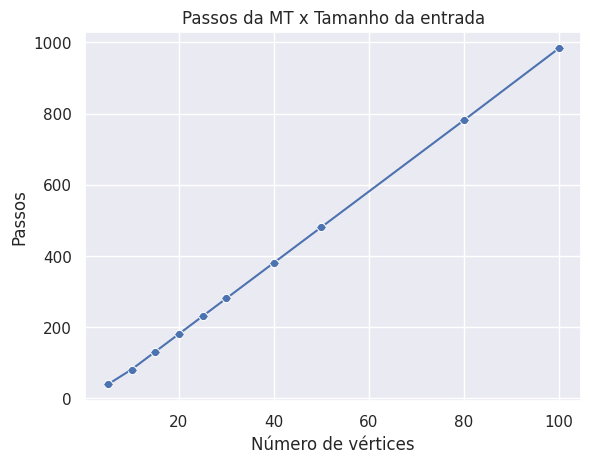

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set_theme()

df = pd.DataFrame({
    "x": [r[0] for r in results],
    "y": [r[1] for r in results],
    "err": [r[2] for r in results]
})

plt.figure()

sns.lineplot(
    data=df,
    x="x",
    y="y",
    marker="o",
    err_style="bars",
    errorbar=None
)

plt.errorbar(
    df["x"],
    df["y"],
    yerr=df["err"],
    fmt="none",
    capsize=3
)

plt.xlabel("Número de vértices")
plt.ylabel("Passos")
plt.title("Passos da MT x Tamanho da entrada")
plt.grid(True)

plt.show()

# 6. DISCUSSÃO

## Análise dos Resultados

O crescimento de passos do autômato tem um crescimento


## Comparação com Complexidade Teórica


## Dificuldades encontradas

# 7. CONCLUSÃO

## Principais Aprendizados

- A máquina de turing permite